In [54]:
# Importo librerias necesarias para analisis y modelado
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import *
import streamlit as st
import holidays

In [55]:
# Cargo los dataframes de ventas y competencia desde los archivos CSV
ventas = pd.read_csv('../data/raw/entrenamiento/ventas.csv')
competencia = pd.read_csv('../data/raw/entrenamiento/competencia.csv')

# Muestro las dimensiones de cada dataframe
print(f"Ventas shape: {ventas.shape}")
print(f"Competencia shape: {competencia.shape}")

Ventas shape: (3552, 10)
Competencia shape: (3552, 5)


In [56]:
# Muestro las primeras filas del dataframe de ventas
ventas.head()

,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74


In [57]:
# Muestro las primeras filas del dataframe de competencia
competencia.head()

,fecha,producto_id,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,82.96,111.88,97.43
1,2021-10-25,PROD_002,112.56,108.61,115.58
2,2021-10-25,PROD_003,79.79,78.44,80.11
3,2021-10-25,PROD_004,72.60,67.29,74.45
4,2021-10-25,PROD_005,37.71,33.60,33.07


In [58]:
# Valido la calidad de datos del dataframe ventas
print("=== INFORME DE CALIDAD DE DATOS - VENTAS ===\n")

# 1. Tipos de datos
print("--- TIPOS DE DATOS ---")
print(ventas.dtypes)

# 2. Valores nulos
print("\n--- VALORES NULOS ---")
print(ventas.isnull().sum())

# 3. Filas duplicadas
print("\n--- FILAS DUPLICADAS ---")
print(f"Total duplicados: {ventas.duplicated().sum()}")

# 4. Estadisticos descriptivos
print("\n--- ESTADISTICOS DESCRIPTIVOS ---")
print(ventas.describe())

=== INFORME DE CALIDAD DE DATOS - VENTAS ===

--- TIPOS DE DATOS ---
fecha                 object
producto_id           object
nombre                object
categoria             object
subcategoria          object
precio_base            int64
es_estrella             bool
unidades_vendidas      int64
precio_venta         float64
ingresos             float64
dtype: object

--- VALORES NULOS ---
fecha                0
producto_id          0
nombre               0
categoria            0
subcategoria         0
precio_base          0
es_estrella          0
unidades_vendidas    0
precio_venta         0
ingresos             0
dtype: int64

--- FILAS DUPLICADAS ---
Total duplicados: 0

--- ESTADISTICOS DESCRIPTIVOS ---
       precio_base  unidades_vendidas  precio_venta      ingresos
count  3552.000000         3552.00000   3552.000000   3552.000000
mean    123.125000            4.87866    121.816546    605.972323
std     165.576753            6.31102    164.017963   1079.071192
min      20.0000

In [59]:
# Valido la calidad de datos del dataframe competencia
print("=== INFORME DE CALIDAD DE DATOS - COMPETENCIA ===\n")

# 1. Tipos de datos
print("--- TIPOS DE DATOS ---")
print(competencia.dtypes)

# 2. Valores nulos
print("\n--- VALORES NULOS ---")
print(competencia.isnull().sum())

# 3. Filas duplicadas
print("\n--- FILAS DUPLICADAS ---")
print(f"Total duplicados: {competencia.duplicated().sum()}")

# 4. Estadisticos descriptivos
print("\n--- ESTADISTICOS DESCRIPTIVOS ---")
print(competencia.describe())

=== INFORME DE CALIDAD DE DATOS - COMPETENCIA ===

--- TIPOS DE DATOS ---
fecha            object
producto_id      object
Amazon          float64
Decathlon       float64
Deporvillage    float64
dtype: object

--- VALORES NULOS ---
fecha           0
producto_id     0
Amazon          0
Decathlon       0
Deporvillage    0
dtype: int64

--- FILAS DUPLICADAS ---
Total duplicados: 0

--- ESTADISTICOS DESCRIPTIVOS ---
            Amazon    Decathlon  Deporvillage
count  3552.000000  3552.000000   3552.000000
mean    118.623407   111.412182    118.894628
std     156.095628   148.508132    160.216448
min      16.850000    15.450000     16.770000
25%      47.117500    43.285000     47.310000
50%      73.180000    66.285000     72.700000
75%     114.342500   111.172500    114.985000
max     858.350000   867.337500    932.325000


In [60]:
# Convierto la columna fecha a datetime en ambos dataframes
ventas['fecha'] = pd.to_datetime(ventas['fecha'])
competencia['fecha'] = pd.to_datetime(competencia['fecha'])

print("Fecha convertida a datetime en ambos dataframes")
print(f"Ventas fecha dtype: {ventas['fecha'].dtype}")
print(f"Competencia fecha dtype: {competencia['fecha'].dtype}")

Fecha convertida a datetime en ambos dataframes
Ventas fecha dtype: datetime64[ns]
Competencia fecha dtype: datetime64[ns]


In [61]:
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 253.3+ KB


In [62]:
competencia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   fecha         3552 non-null   datetime64[ns]
 1   producto_id   3552 non-null   object        
 2   Amazon        3552 non-null   float64       
 3   Decathlon     3552 non-null   float64       
 4   Deporvillage  3552 non-null   float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 138.9+ KB


In [63]:
# Uno los dataframes de ventas y competencia usando fecha y producto_id como claves
df = pd.merge(ventas, competencia, on=['fecha', 'producto_id'], how='inner')

print(f"Dataframe unificado shape: {df.shape}")
df.head()

Dataframe unificado shape: (3552, 13)


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,Amazon,Decathlon,Deporvillage
0,2021-10-25,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,6,118.36,710.16,82.96,111.88,97.43
1,2021-10-25,PROD_002,Adidas Ultraboost 23,Running,Zapatillas Running,135,True,10,136.82,1368.20,112.56,108.61,115.58
2,2021-10-25,PROD_003,Asics Gel Nimbus 25,Running,Zapatillas Running,85,False,2,84.93,169.86,79.79,78.44,80.11
3,2021-10-25,PROD_004,New Balance Fresh Foam X 1080v12,Running,Zapatillas Running,75,False,2,75.42,150.84,72.60,67.29,74.45
4,2021-10-25,PROD_005,Nike Dri-FIT Miler,Running,Ropa Running,35,False,2,35.87,71.74,37.71,33.60,33.07


In [64]:
# Muestro la estructura del dataframe unificado df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3552 entries, 0 to 3551
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              3552 non-null   datetime64[ns]
 1   producto_id        3552 non-null   object        
 2   nombre             3552 non-null   object        
 3   categoria          3552 non-null   object        
 4   subcategoria       3552 non-null   object        
 5   precio_base        3552 non-null   int64         
 6   es_estrella        3552 non-null   bool          
 7   unidades_vendidas  3552 non-null   int64         
 8   precio_venta       3552 non-null   float64       
 9   ingresos           3552 non-null   float64       
 10  Amazon             3552 non-null   float64       
 11  Decathlon          3552 non-null   float64       
 12  Deporvillage       3552 non-null   float64       
dtypes: bool(1), datetime64[ns](1), float64(5), int64(2), object(4)


In [65]:
# Extraigo caracteristicas temporales de la fecha para el analisis
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.dayofweek
df['nombre_dia'] = df['fecha'].dt.day_name()

# Defino Black Fridays (noviembre)
df['es_black_friday'] = (df['mes'] == 11) & (df['dia'] >= 22) & (df['dia'] <= 30)

print("Features temporales creadas")
print(f"Años en los datos: {df['año'].unique()}")
print(f"Black Fridays: {df['es_black_friday'].sum()} registros")

Features temporales creadas
Años en los datos: [2021 2022 2023 2024]
Black Fridays: 864 registros


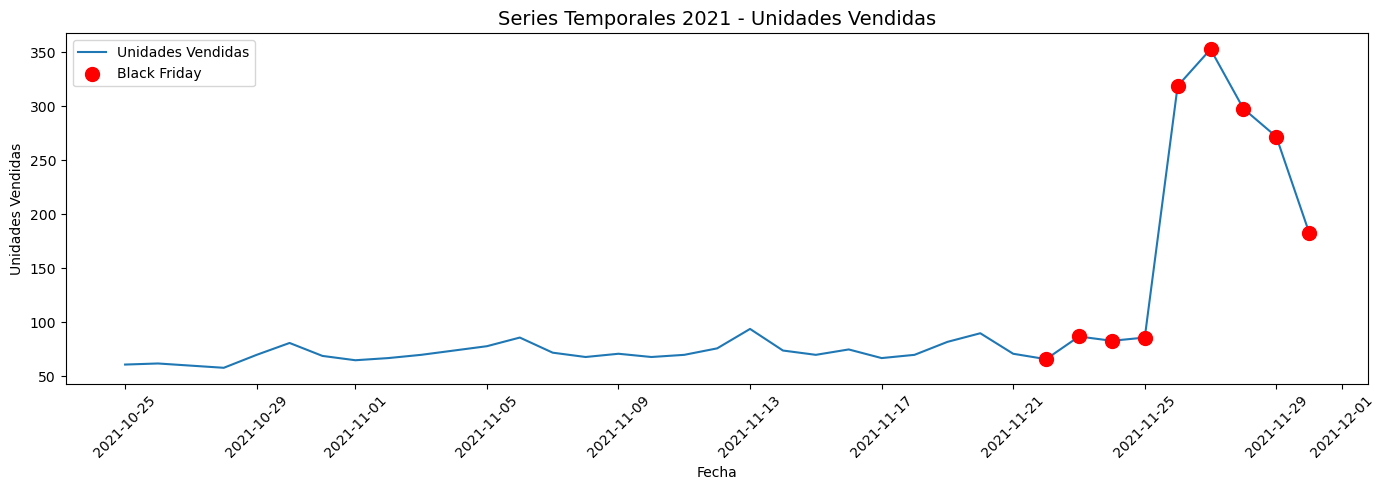

In [66]:
# Grafico de series temporales de unidades vendidas por año
# Agrego las ventas diarias
ventas_diarias = df.groupby('fecha')['unidades_vendidas'].sum().reset_index()
ventas_diarias['año'] = ventas_diarias['fecha'].dt.year
ventas_diarias['dia_semana'] = ventas_diarias['fecha'].dt.dayofweek
ventas_diarias['es_black_friday'] = (ventas_diarias['fecha'].dt.month == 11) & (ventas_diarias['fecha'].dt.day >= 22)

# Grafico 2021
plt.figure(figsize=(14, 5))
ventas_2021 = ventas_diarias[ventas_diarias['año'] == 2021]
sns.lineplot(data=ventas_2021, x='fecha', y='unidades_vendidas', label='Unidades Vendidas')
# Marco los Black Fridays
bf_2021 = ventas_2021[ventas_2021['es_black_friday']]
plt.scatter(bf_2021['fecha'], bf_2021['unidades_vendidas'], color='red', s=100, zorder=5, label='Black Friday')
plt.title('Series Temporales 2021 - Unidades Vendidas', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

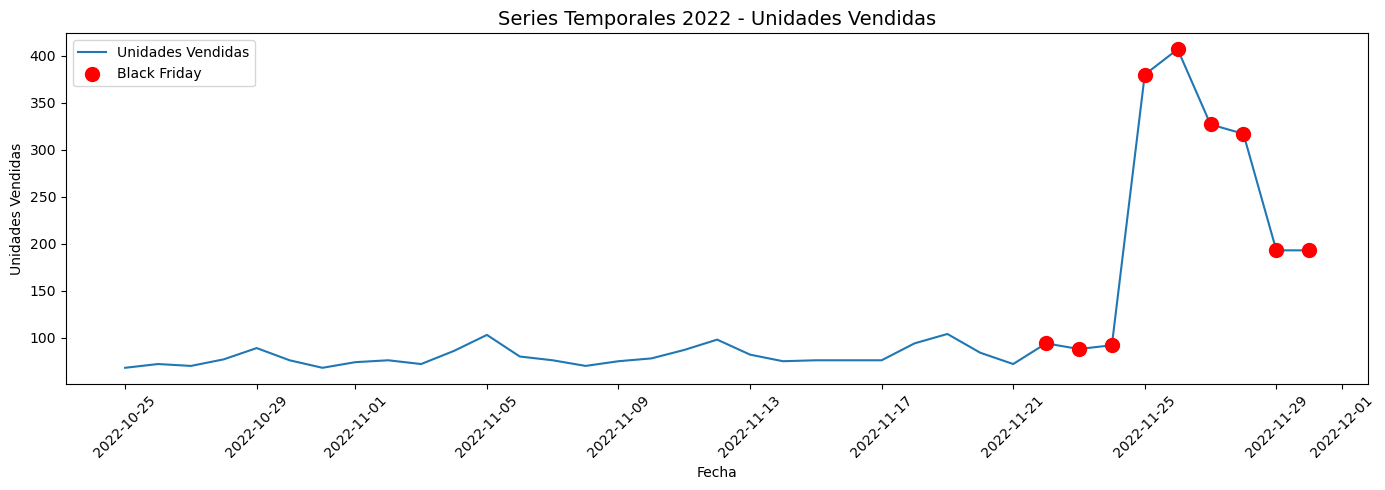

In [67]:
# Grafico 2022
plt.figure(figsize=(14, 5))
ventas_2022 = ventas_diarias[ventas_diarias['año'] == 2022]
sns.lineplot(data=ventas_2022, x='fecha', y='unidades_vendidas', label='Unidades Vendidas')
bf_2022 = ventas_2022[ventas_2022['es_black_friday']]
plt.scatter(bf_2022['fecha'], bf_2022['unidades_vendidas'], color='red', s=100, zorder=5, label='Black Friday')
plt.title('Series Temporales 2022 - Unidades Vendidas', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Unidades Vendidas')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\m26344676\AppData\Local\Temp\ipykernel_26344\2595925975.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orden_dias, y=ventas_dia_semana.values, palette='Blues_d')


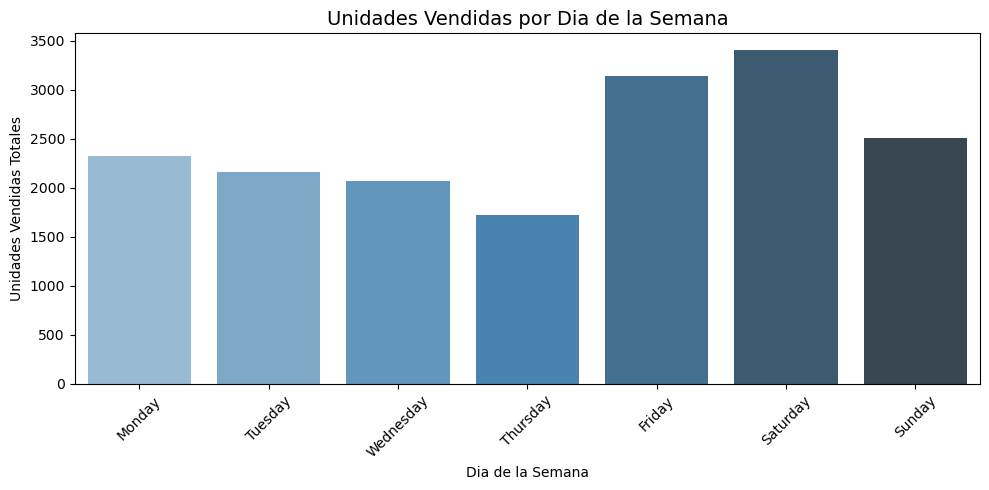

In [68]:
# Grafico de unidades vendidas por dia de la semana
plt.figure(figsize=(10, 5))
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_dia_semana = df.groupby('nombre_dia')['unidades_vendidas'].sum().reindex(orden_dias)
sns.barplot(x=orden_dias, y=ventas_dia_semana.values, palette='Blues_d')
plt.title('Unidades Vendidas por Dia de la Semana', fontsize=14)
plt.xlabel('Dia de la Semana')
plt.ylabel('Unidades Vendidas Totales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\m26344676\AppData\Local\Temp\ipykernel_26344\2810568349.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_categoria.index, y=ventas_categoria.values, palette='viridis')


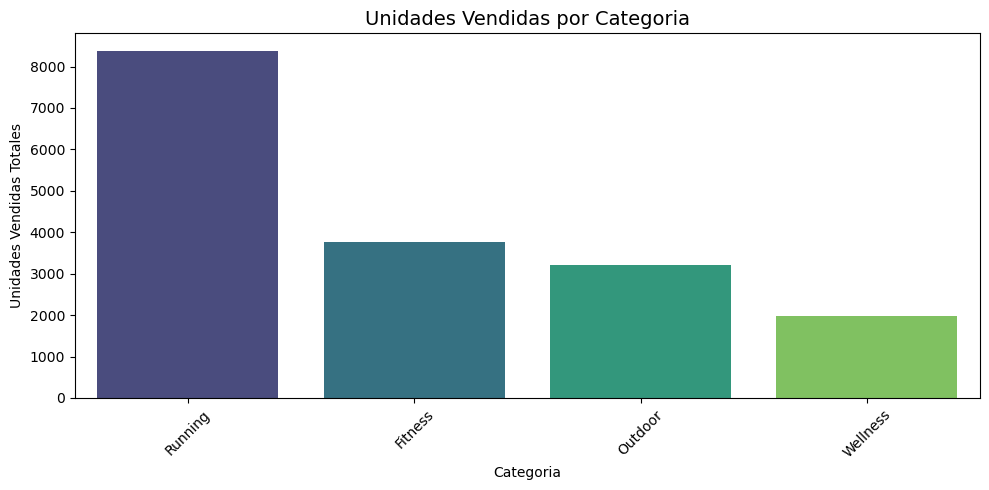

In [69]:
# Grafico de unidades vendidas por categoria
plt.figure(figsize=(10, 5))
ventas_categoria = df.groupby('categoria')['unidades_vendidas'].sum().sort_values(ascending=False)
sns.barplot(x=ventas_categoria.index, y=ventas_categoria.values, palette='viridis')
plt.title('Unidades Vendidas por Categoria', fontsize=14)
plt.xlabel('Categoria')
plt.ylabel('Unidades Vendidas Totales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\m26344676\AppData\Local\Temp\ipykernel_26344\278243038.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_subcat.index, y=ventas_subcat.values, palette='coolwarm')


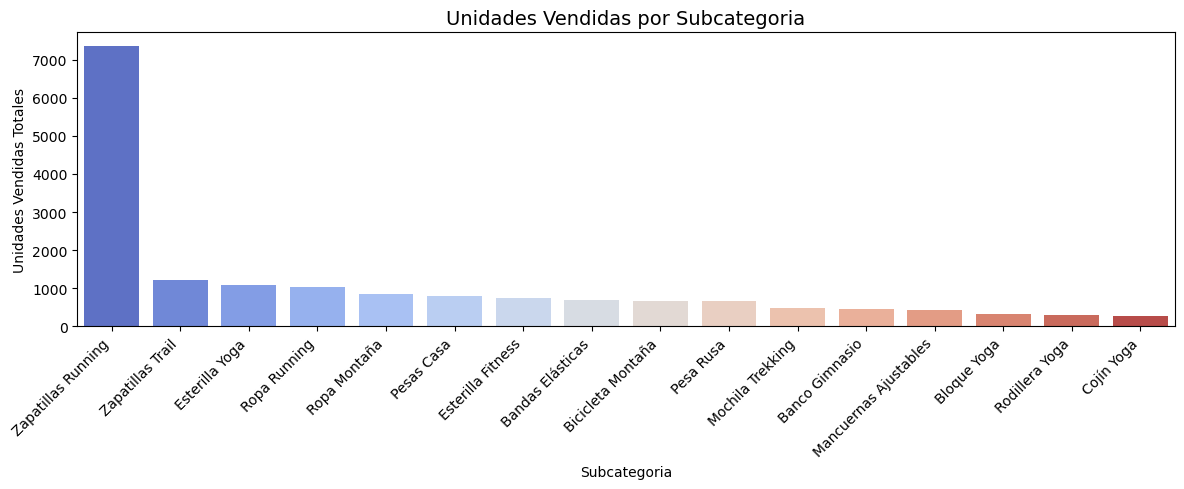

In [70]:
# Grafico de unidades vendidas por subcategoria
plt.figure(figsize=(12, 5))
ventas_subcat = df.groupby('subcategoria')['unidades_vendidas'].sum().sort_values(ascending=False)
sns.barplot(x=ventas_subcat.index, y=ventas_subcat.values, palette='coolwarm')
plt.title('Unidades Vendidas por Subcategoria', fontsize=14)
plt.xlabel('Subcategoria')
plt.ylabel('Unidades Vendidas Totales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\m26344676\AppData\Local\Temp\ipykernel_26344\2436299520.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_productos.index, x=top_productos.values, palette='rocket')


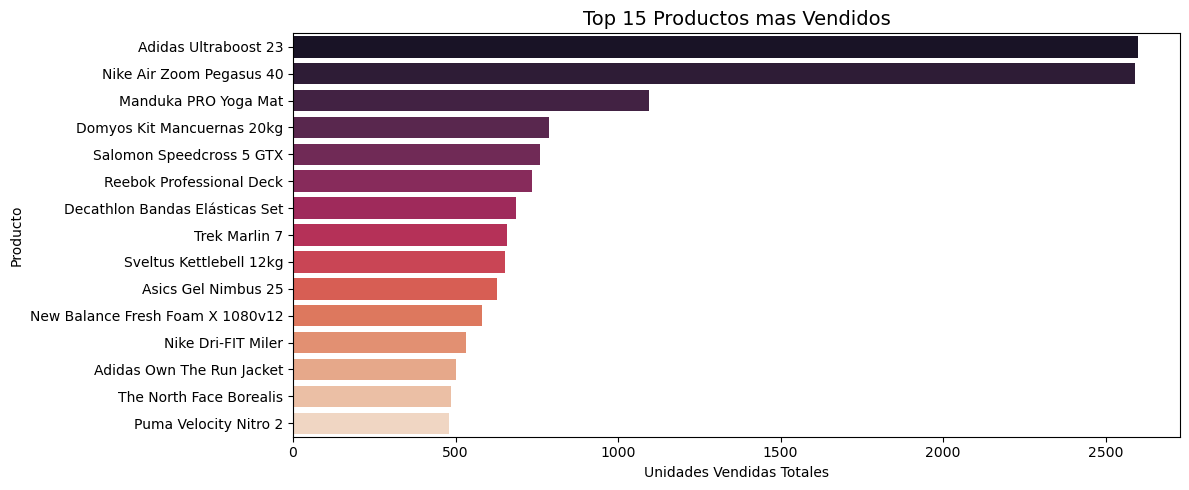

In [71]:
# Grafico de top 15 productos mas vendidos
plt.figure(figsize=(12, 5))
top_productos = df.groupby('nombre')['unidades_vendidas'].sum().sort_values(ascending=False).head(15)
sns.barplot(y=top_productos.index, x=top_productos.values, palette='rocket')
plt.title('Top 15 Productos mas Vendidos', fontsize=14)
plt.xlabel('Unidades Vendidas Totales')
plt.ylabel('Producto')
plt.tight_layout()
plt.show()

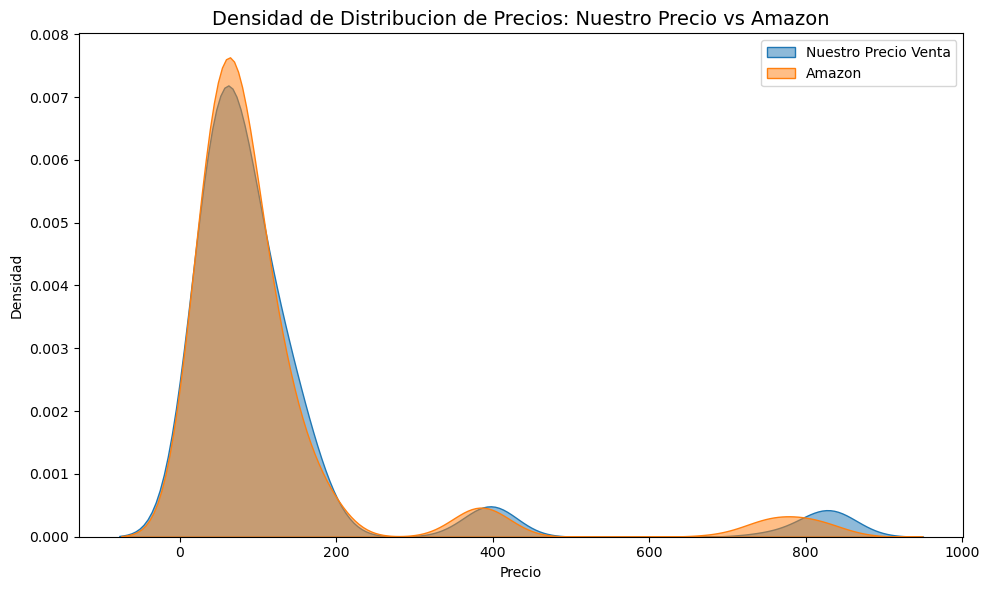

In [72]:
# Grafico de densidad de precios: nuestro precio vs Amazon
plt.figure(figsize=(10, 6))
sns.kdeplot(df['precio_venta'], label='Nuestro Precio Venta', fill=True, alpha=0.5)
sns.kdeplot(df['Amazon'], label='Amazon', fill=True, alpha=0.5)
plt.title('Densidad de Distribucion de Precios: Nuestro Precio vs Amazon', fontsize=14)
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
# Creo variables temporales y de calendario usando holidays de Espana
es_holidays = holidays.Spain(years=df['año'].unique())

# Variables temporales basicas
df['año'] = df['fecha'].dt.year
df['mes'] = df['fecha'].dt.month
df['dia_mes'] = df['fecha'].dt.day
df['dia_semana'] = df['fecha'].dt.dayofweek
df['semana_del_año'] = df['fecha'].dt.isocalendar().week
df['trimestre'] = df['fecha'].dt.quarter
df['dia_del_año'] = df['fecha'].dt.dayofyear

# Fin de semana (viernes 5, sabado 6, domingo 0)
df['es_fin_semana'] = df['dia_semana'].isin([5, 6]).astype(int)

# Festivos de Espana
df['es_festivo'] = df['fecha'].isin(es_holidays).astype(int)

# Black Friday (4to jueves de noviembre)
from calendar import monthrange
def get_black_friday(year):
    nov = pd.date_range(start=f'{year}-11-01', periods=30, freq='D')
    thursday = [d for d in nov if d.weekday() == 3]
    return thursday[3] if len(thursday) > 3 else None

black_fridays = [get_black_friday(y) for y in df['año'].unique() if get_black_friday(y)]
df['es_black_friday'] = df['fecha'].isin(black_fridays).astype(int)

# Cyber Monday (lunes siguiente al Black Friday)
cyber_mondays = [bf + pd.Timedelta(days=3) for bf in black_fridays]
df['es_cyber_monday'] = df['fecha'].isin(cyber_mondays).astype(int)

# Comienzo y fin de mes
df['es_comienzo_mes'] = (df['dia_mes'] <= 5).astype(int)
df['es_fin_mes'] = (df['dia_mes'] >= 25).astype(int)

# Primer lunes del mes
def es_primer_lunes(row):
    primer_dia = pd.Timestamp(year=row['año'], month=row['mes'], day=1)
    primer_lunes = primer_dia + pd.Timedelta(days=(7 - primer_dia.weekday()) % 7)
    return 1 if row['fecha'] == primer_lunes else 0

df['es_primer_lunes_mes'] = df.apply(es_primer_lunes, axis=1)

# Rebajas de enero (1 al 31 de enero)
df['es_rebajas'] = ((df['mes'] == 1) & (df['dia_mes'] <= 31)).astype(int)

print("Variables temporales y de calendario creadas")
print(f"Festivos detectados: {df['es_festivo'].sum()}")
print(f"Black Fridays: {df['es_black_friday'].sum()}")
print(f"Cyber Mondays: {df['es_cyber_monday'].sum()}")

Variables temporales y de calendario creadas
Festivos detectados: 96
Black Fridays: 96
Cyber Mondays: 72


C:\Users\m26344676\AppData\Local\Temp\ipykernel_26344\1744720567.py:17: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  df['es_festivo'] = df['fecha'].isin(es_holidays).astype(int)


In [74]:
# Creo lags y media movil de unidades vendidas por producto y año
df = df.sort_values(['producto_id', 'fecha']).reset_index(drop=True)

lags = [1, 2, 3, 4, 5, 6, 7]
for lag in lags:
    df[f'lag_{lag}'] = df.groupby(['producto_id', 'año'])['unidades_vendidas'].shift(lag)

df['rolling_mean_7'] = df.groupby(['producto_id', 'año'])['unidades_vendidas'].transform(
    lambda x: x.rolling(window=7, min_periods=7).mean()
)

columnas_lags = [f'lag_{i}' for i in lags] + ['rolling_mean_7']
filas_antes = len(df)
df = df.dropna(subset=columnas_lags)
filas_despues = len(df)

print(f"Lags y media movil de 7 dias creados")
print(f"Registros antes: {filas_antes}")
print(f"Registros despues: {filas_despues}")
print(f"Registros eliminados: {filas_antes - filas_despues}")

Lags y media movil de 7 dias creados
Registros antes: 3552
Registros despues: 2880
Registros eliminados: 672


In [75]:
df.groupby('año').size()

año
2021    720
2022    720
2023    720
2024    720
dtype: int64

In [76]:
# Creo variable descuento porcentaje: diferencia entre precio venta y precio base
df['descuento_pct'] = ((df['precio_venta'] - df['precio_base']) / df['precio_base']) * 100

print(f"Variable descuento_pct creada")
print(f"Media descuento: {df['descuento_pct'].mean():.2f}%")
print(f"Min descuento: {df['descuento_pct'].min():.2f}%")
print(f"Max descuento: {df['descuento_pct'].max():.2f}%")

df.head()

Variable descuento_pct creada
Media descuento: -1.35%
Min descuento: -15.00%
Max descuento: 2.99%


,fecha,producto_id,nombre,categoria,subcategoria,precio_base,es_estrella,unidades_vendidas,precio_venta,ingresos,...,es_rebajas,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,rolling_mean_7,descuento_pct
7,2021-11-01,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,7,115.07,805.49,...,0,9.0,12.0,12.0,7.0,8.0,8.0,6.0,9.000000,0.060870
8,2021-11-02,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,116.10,1161.00,...,0,7.0,9.0,12.0,12.0,7.0,8.0,8.0,9.285714,0.956522
9,2021-11-03,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,11,114.58,1260.38,...,0,10.0,7.0,9.0,12.0,12.0,7.0,8.0,9.714286,-0.365217
10,2021-11-04,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,12,112.23,1346.76,...,0,11.0,10.0,7.0,9.0,12.0,12.0,7.0,10.428571,-2.408696
11,2021-11-05,PROD_001,Nike Air Zoom Pegasus 40,Running,Zapatillas Running,115,True,10,113.81,1138.10,...,0,12.0,11.0,10.0,7.0,9.0,12.0,12.0,10.142857,-1.034783


In [77]:
# Creo variable precio_competencia como promedio de los competidores
df['precio_competencia'] = (df['Amazon'] + df['Decathlon'] + df['Deporvillage']) / 3

# Creo ratio_precio: nuestro precio entre precio promedio competencia
df['ratio_precio'] = df['precio_venta'] / df['precio_competencia']

# Elimino las columnas individuales de competencia
df = df.drop(columns=['Amazon', 'Decathlon', 'Deporvillage'])

print(f"Variables precio_competencia y ratio_precio creadas")
print(f"Columnas restantes: {df.shape[1]}")

Variables precio_competencia y ratio_precio creadas
Columnas restantes: 38


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2880 entries, 7 to 3551
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   fecha                2880 non-null   datetime64[ns]
 1   producto_id          2880 non-null   object        
 2   nombre               2880 non-null   object        
 3   categoria            2880 non-null   object        
 4   subcategoria         2880 non-null   object        
 5   precio_base          2880 non-null   int64         
 6   es_estrella          2880 non-null   bool          
 7   unidades_vendidas    2880 non-null   int64         
 8   precio_venta         2880 non-null   float64       
 9   ingresos             2880 non-null   float64       
 10  año                  2880 non-null   int32         
 11  mes                  2880 non-null   int32         
 12  dia                  2880 non-null   int32         
 13  dia_semana           2880 non-null   i

In [79]:
# Creo copias de nombre, categoria y subcategoria para one-hot encoding
df['nombre_h'] = df['nombre']
df['categoria_h'] = df['categoria']
df['subcategoria_h'] = df['subcategoria']

# Aplico one-hot encoding solo a las 3 variables _h
df = pd.get_dummies(df, columns=['nombre_h', 'categoria_h', 'subcategoria_h'], drop_first=False)

print(f"One-hot encoding aplicado")
print(f"Total columnas: {df.shape[1]}")

One-hot encoding aplicado
Total columnas: 82


In [80]:
# Guardo el dataframe procesado en data/processed
df.to_csv('../data/processed/df.csv', index=False)

print(f"Dataframe guardado en ../data/processed/df.csv")
print(f"Shape: {df.shape}")

Dataframe guardado en ../data/processed/df.csv
Shape: (2880, 82)


In [81]:
df.columns.tolist()

['fecha',
 'producto_id',
 'nombre',
 'categoria',
 'subcategoria',
 'precio_base',
 'es_estrella',
 'unidades_vendidas',
 'precio_venta',
 'ingresos',
 'año',
 'mes',
 'dia',
 'dia_semana',
 'nombre_dia',
 'es_black_friday',
 'dia_mes',
 'semana_del_año',
 'trimestre',
 'dia_del_año',
 'es_fin_semana',
 'es_festivo',
 'es_cyber_monday',
 'es_comienzo_mes',
 'es_fin_mes',
 'es_primer_lunes_mes',
 'es_rebajas',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_4',
 'lag_5',
 'lag_6',
 'lag_7',
 'rolling_mean_7',
 'descuento_pct',
 'precio_competencia',
 'ratio_precio',
 'nombre_h_Adidas Own The Run Jacket',
 'nombre_h_Adidas Ultraboost 23',
 'nombre_h_Asics Gel Nimbus 25',
 'nombre_h_Bowflex SelectTech 552',
 'nombre_h_Columbia Silver Ridge',
 'nombre_h_Decathlon Bandas Elásticas Set',
 'nombre_h_Domyos BM900',
 'nombre_h_Domyos Kit Mancuernas 20kg',
 'nombre_h_Gaiam Premium Yoga Block',
 'nombre_h_Liforme Yoga Pad',
 'nombre_h_Lotuscrafts Yoga Bolster',
 'nombre_h_Manduka PRO Yoga Mat',
 'nombre_h_M

In [82]:
# Divido df en train (2021-2023) y validation (2024)
train_df = df[df['año'].isin([2021, 2022, 2023])]
validation_df = df[df['año'] == 2024]

print(f"Train_df registros: {len(train_df)}")
print(f"Validation_df registros: {len(validation_df)}")

Train_df registros: 2160
Validation_df registros: 720


In [83]:
# Entreno HistGradientBoostingRegressor con parametros conservadores
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Defino target
target = 'unidades_vendidas'

# Selecciono features (excluyo fecha, ingresos y columnas object)
exclude_cols = ['fecha', 'ingresos', 'producto_id', 'nombre', 'categoria', 'subcategoria', 'nombre_dia']
feature_cols = [col for col in df.columns if col not in exclude_cols and col != target]

X_train = train_df[feature_cols]
y_train = train_df[target]
X_val = validation_df[feature_cols]
y_val = validation_df[target]

# Modelo con parametros conservadores
model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=500,
    max_depth=6,
    min_samples_leaf=20,
    l2_regularization=1.0,
    random_state=42
)

model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_val)

# Baseline naive: media de entrenamiento
y_pred_baseline = [y_train.mean()] * len(y_val)

# Calculo metricas
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mae_model = mean_absolute_error(y_val, y_pred)
rmse_model = np.sqrt(mean_squared_error(y_val, y_pred))
mape_model = mape(y_val, y_pred)

mae_baseline = mean_absolute_error(y_val, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_val, y_pred_baseline))
mape_baseline = mape(y_val, y_pred_baseline)

print('=== RESULTADOS MODELO vs BASELINE ===')
print(f'\nModelo HistGradientBoostingRegressor:')
print(f'  MAE:  {mae_model:.2f}')
print(f'  RMSE: {rmse_model:.2f}')
print(f'  MAPE: {mape_model:.2f}%')

print(f'\nBaseline (media):')
print(f'  MAE:  {mae_baseline:.2f}')
print(f'  RMSE: {rmse_baseline:.2f}')
print(f'  MAPE: {mape_baseline:.2f}%')

=== RESULTADOS MODELO vs BASELINE ===

Modelo HistGradientBoostingRegressor:
  MAE:  0.82
  RMSE: 1.62
  MAPE: 15.95%

Baseline (media):
  MAE:  3.67
  RMSE: 6.69
  MAPE: 93.02%


Productos estrella: 7


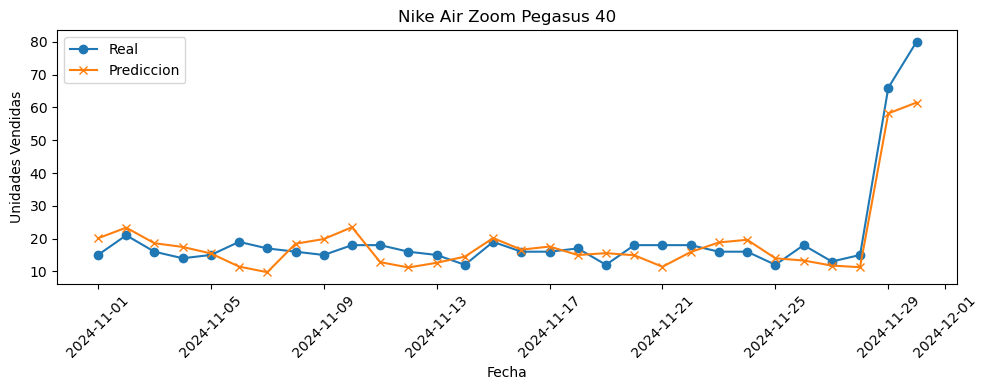

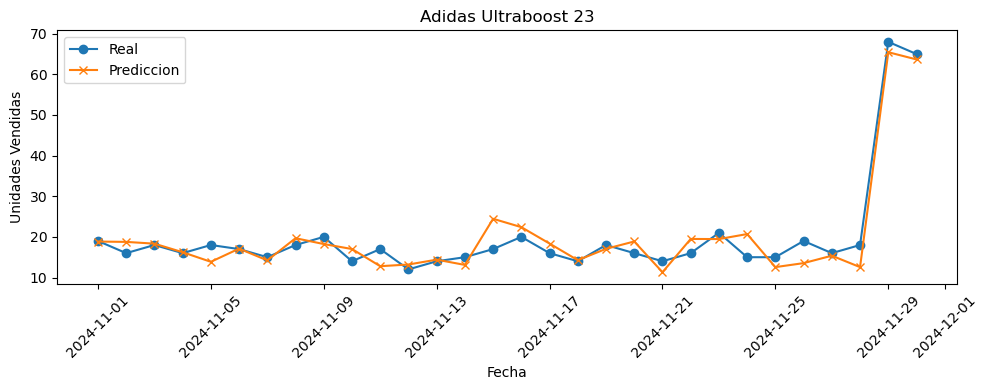

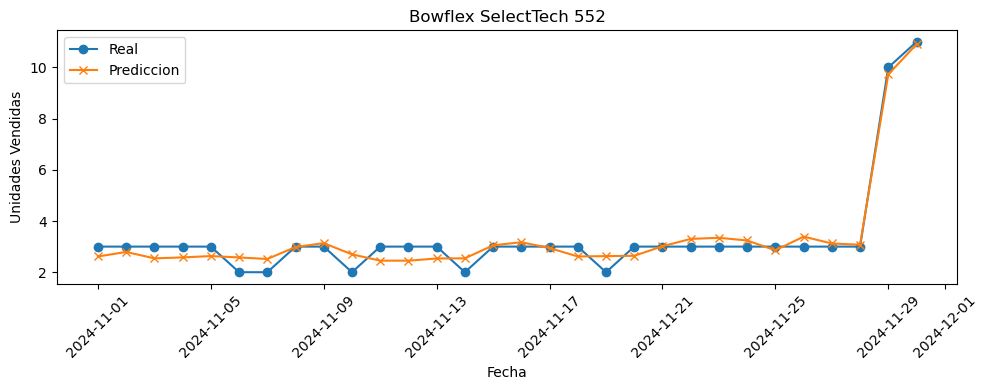

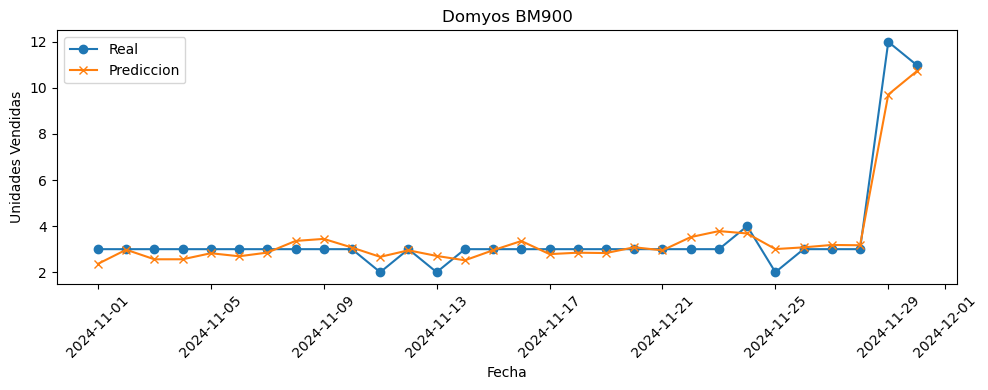

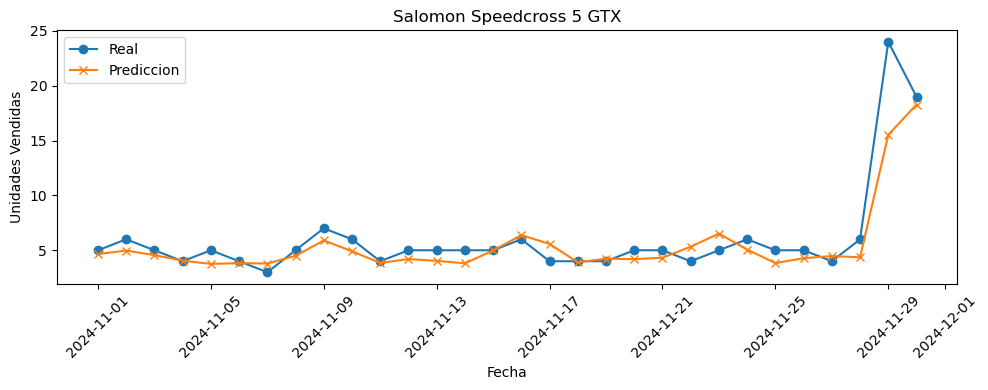

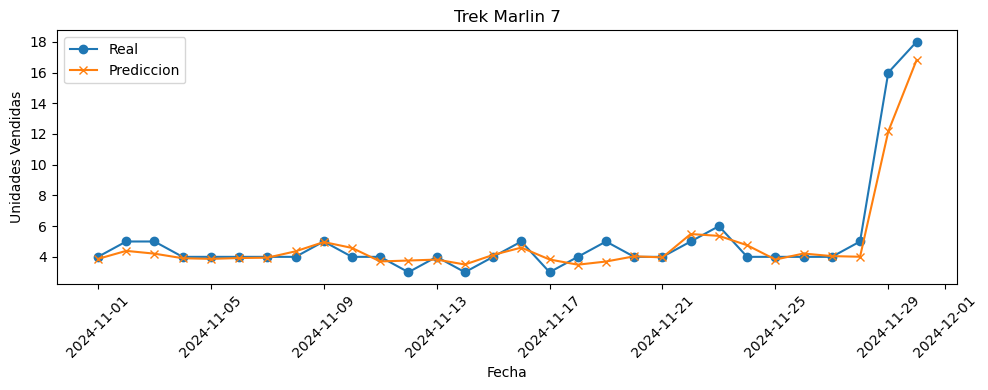

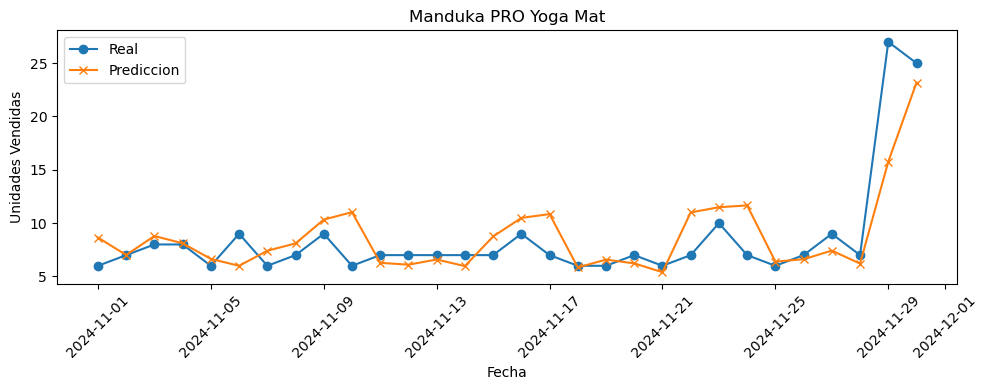

In [84]:
# Predicciones para noviembre 2024 por producto estrella
nov2024 = validation_df[(validation_df['mes'] == 11)]

productos_estrella = df[df['es_estrella'] == True]['nombre'].unique()
print(f'Productos estrella: {len(productos_estrella)}')

for producto in productos_estrella:
    prod_data = nov2024[nov2024['nombre'] == producto].sort_values('fecha')
    
    if len(prod_data) > 0:
        X_prod = prod_data[feature_cols]
        y_actual = prod_data[target].values
        y_pred_prod = model.predict(X_prod)
        
        plt.figure(figsize=(10, 4))
        plt.plot(prod_data['fecha'], y_actual, label='Real', marker='o')
        plt.plot(prod_data['fecha'], y_pred_prod, label='Prediccion', marker='x')
        plt.title(f'{producto}', fontsize=12)
        plt.xlabel('Fecha')
        plt.ylabel('Unidades Vendidas')
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()